# Auto Regression Moving Average Hands-On

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Import important libraries
import pandas as pd
import yfinance as yf
import datetime as dt
from nsepy import get_history as gh
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA # Can be used for MA, ARMA, and ARIMA
from stockFunctions import rmsemape
from stockFunctions import graph
from stockFunctions import conversionSingle

In [3]:
# Dataset collection
stock_symbol = "RELIANCE.NS"
Stk_data =yf.download(stock_symbol, start = "2023-01-01", end = "2023-07-01")
Stk_data.info() # Check the quality of dataset

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 122 entries, 2023-01-02 to 2023-06-30
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   122 non-null    float64
 1   (High, RELIANCE.NS)    122 non-null    float64
 2   (Low, RELIANCE.NS)     122 non-null    float64
 3   (Open, RELIANCE.NS)    122 non-null    float64
 4   (Volume, RELIANCE.NS)  122 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 5.7 KB


In [4]:
# Check parameters and values in the dataset
Stk_data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2023-01-02,1170.477783,1171.886424,1157.891000,1158.708901,5316175
2023-01-03,1161.912354,1169.160003,1157.709267,1165.547536,7658932
2023-01-04,1144.418213,1163.730055,1142.350684,1161.889687,9264891
2023-01-05,1142.373535,1152.529332,1137.806870,1146.667607,13637099
2023-01-06,1152.756348,1157.777455,1144.304622,1148.098818,6349597
...,...,...,...,...,...
2023-06-23,1142.691528,1151.165970,1141.441900,1149.121157,6628570
2023-06-26,1133.967163,1142.986912,1130.854571,1139.170000,12641159


In [5]:
# Consideration of important parameters of the dataset
Stk_data = Stk_data[["Close", "High", "Low", "Open"]]
Stk_data

Price,Close,High,Low,Open
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,
2023-01-02,1170.477783,1171.886424,1157.891000,1158.708901
2023-01-03,1161.912354,1169.160003,1157.709267,1165.547536
2023-01-04,1144.418213,1163.730055,1142.350684,1161.889687
2023-01-05,1142.373535,1152.529332,1137.806870,1146.667607
2023-01-06,1152.756348,1157.777455,1144.304622,1148.098818
...,...,...,...,...
2023-06-23,1142.691528,1151.165970,1141.441900,1149.121157
2023-06-26,1133.967163,1142.986912,1130.854571,1139.170000


In [6]:
# Separate the functions to carry out univariate analysis
Column = "Close"

In [7]:
# Model creation
MMS = MinMaxScaler()
Data1 = MMS.fit_transform(Stk_data[[Column]])
print("Length of data is:", Data1.shape)

Length of data is: (122, 1)


In [8]:
# Model optimisation
Orders = [(1,0,1), (1,0,2), (2,0,1), (2,0,2)]
for i in Orders: 
    # To print i
    Model = ARIMA(Data1, order=i)
    Model_fit = Model.fit()
        # Making a prediction
    Y_pred = Model_fit.predict(0, len(Data1)-1)
    print ("Order ={}".format(i))
    rmsemape (Data1, Y_pred)
    print ("*********")
# Note: A lower value is preferred as the best model

Order =(1, 0, 1)
RMSE-Testset: 0.07340570434920222
maPe-Testset: 2843927570020.9263
*********
Order =(1, 0, 2)
RMSE-Testset: 0.07352648075829386
maPe-Testset: 2862657582182.63
*********
Order =(2, 0, 1)
RMSE-Testset: 0.07344517031066249
maPe-Testset: 2847573055373.2007
*********
Order =(2, 0, 2)
RMSE-Testset: 0.07198077397093995
maPe-Testset: 3177487784182.7905
*********


C:\Users\dilip\anaconda3\envs\aiml1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [9]:
len(Y_pred)

122

In [10]:
# It is noted that for Lag =1, Trend =ct, we got the lowest value for RMSE and MAPE
i = (1,0,1)
Model = ARIMA(Data1, order=i)
Model_fit = Model.fit()
Y_pred = Model_fit.predict(0, len(Data1)-1)
print ("Order ={}".format(i))
rmsemape (Data1, Y_pred)
print ("*********")

Order =(1, 0, 1)
RMSE-Testset: 0.07340570434920222
maPe-Testset: 2843927570020.9263
*********


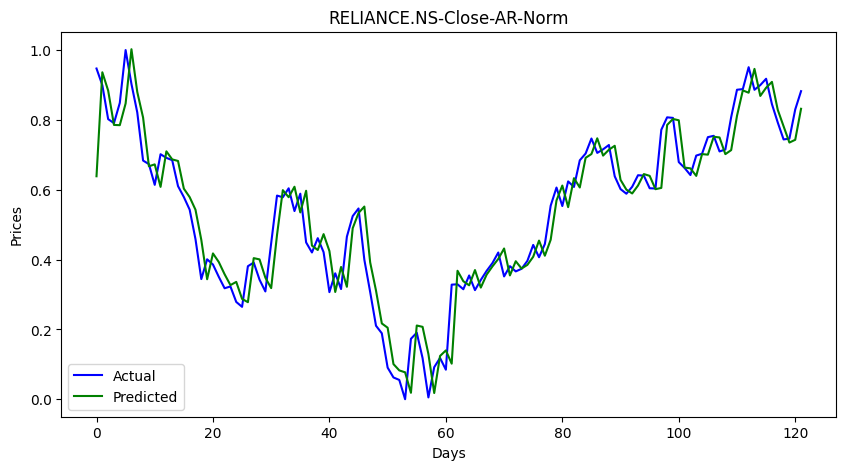

In [11]:
# Visualise model output
graph(Data1, Y_pred, "Actual", "Predicted", "RELIANCE.NS-Close-AR-Norm", "Days", "Prices")

In [12]:
# Checking length of output
len(Data1)

122

In [13]:
# Actual value calculation
TrueValue_A = conversionSingle(Data1, [Column])
Stockprice_Value = MMS.inverse_transform(TrueValue_A)
Actual_Stockprice_Value = conversionSingle(Stockprice_Value, [Column])

In [14]:
# Predicted value calculation
TrueValue_P = conversionSingle(Y_pred, [Column])
Stockprice_Value = MMS.inverse_transform(TrueValue_P)
Predicted_Stockprice_Value = conversionSingle(Stockprice_Value, [Column])

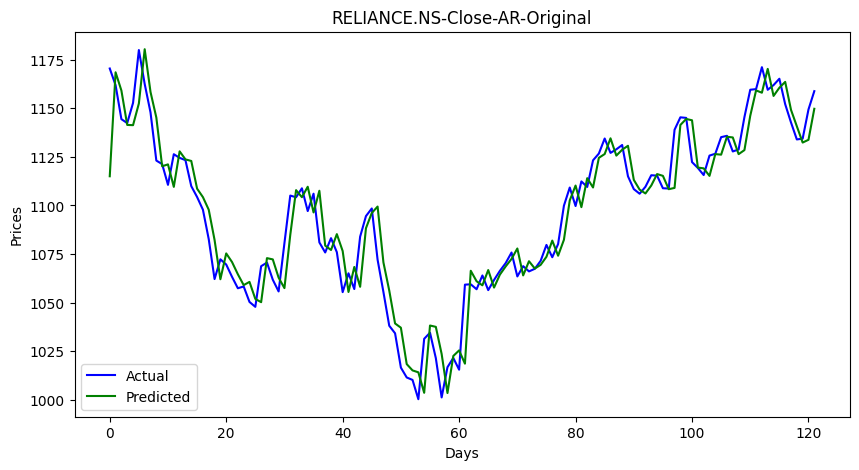

In [15]:
# Visualisation after calculation of actual and predicted values
graph(Actual_Stockprice_Value, Predicted_Stockprice_Value, "Actual", "Predicted", "RELIANCE.NS-Close-AR-Original", "Days", "Prices")

In [16]:
# Determine the RMS and MAP values for actual and predicted
rmsemape (Actual_Stockprice_Value, Predicted_Stockprice_Value)

RMSE-Testset: 13.193653841840396
maPe-Testset: 0.009030220305992908


In [17]:
# Farcasting for subsequent three days
Forecast = Model_fit.predict(len(Data1), len(Data1)+3)
Forecast 

array([0.87777854, 0.86752904, 0.85771868, 0.84832864])

In [18]:
# Carryout forecasting 
FTest_NormalTable = conversionSingle(Forecast , ["Closeforce"])
Stockprice_Original = MMS.inverse_transform(FTest_NormalTable)
Stockprice_Forecast = conversionSingle(Stockprice_Original, ["Closeforce"])
Stockprice_Forecast

,Closeforce
0,1158.007003
1,1156.164798
2,1154.401522
3,1152.713793


In [19]:
# Saving the final forecasted values
Stockprice_Forecast.to_csv("CloseARMA_Forecast.csv", index = False)